# NeqSim Field-Development Building Blocks

This notebook supports Chapter 11. It turns the physical building-block method into executable NeqSim field-development objects and generates the figures used in the chapter.


In [ ]:
from pathlib import Path
import sys
import math
import subprocess

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt

try:
    NOTEBOOK_DIR = Path(__vsc_ipynb_file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()

FIGURES_DIR = NOTEBOOK_DIR.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

PROJECT_ROOT = NOTEBOOK_DIR
for candidate in [NOTEBOOK_DIR] + list(NOTEBOOK_DIR.parents):
    if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
        PROJECT_ROOT = candidate
        break

sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False)
JClass = ns.JClass

FieldConcept = JClass("neqsim.process.fielddevelopment.concept.FieldConcept")
ReservoirInput = JClass("neqsim.process.fielddevelopment.concept.ReservoirInput")
WellsInput = JClass("neqsim.process.fielddevelopment.concept.WellsInput")
InfrastructureInput = JClass("neqsim.process.fielddevelopment.concept.InfrastructureInput")
ConceptEvaluator = JClass("neqsim.process.fielddevelopment.evaluation.ConceptEvaluator")
FlowAssuranceScreener = JClass("neqsim.process.fielddevelopment.screening.FlowAssuranceScreener")
FacilityBuilder = JClass("neqsim.process.fielddevelopment.facility.FacilityBuilder")
DevelopmentOptionRanker = JClass("neqsim.process.fielddevelopment.evaluation.DevelopmentOptionRanker")
Criterion = JClass("neqsim.process.fielddevelopment.evaluation.DevelopmentOptionRanker$Criterion")

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures: {FIGURES_DIR}")


Project root: C:\Users\ESOL\Documents\GitHub\neqsim
Figures: C:\Users\ESOL\Documents\GitHub\neqsim\neqsim-paperlab\books\tpg4230_field_development_and_operations_2026\chapters\ch11_field_development_building_blocks\figures


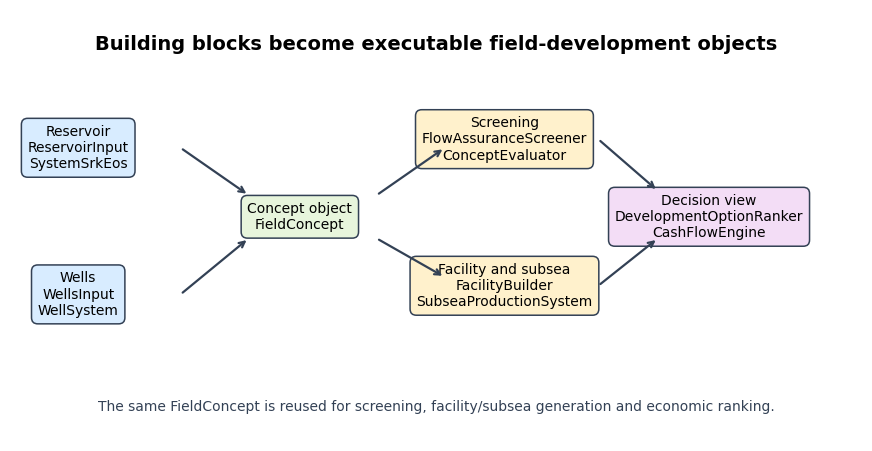

In [2]:
fig, ax = plt.subplots(figsize=(11, 5.6))
ax.axis("off")

nodes = [
    ("Reservoir\nReservoirInput\nSystemSrkEos", 0.08, 0.68, "#d8ecff"),
    ("Wells\nWellsInput\nWellSystem", 0.08, 0.34, "#d8ecff"),
    ("Concept object\nFieldConcept", 0.34, 0.52, "#e7f5dc"),
    ("Screening\nFlowAssuranceScreener\nConceptEvaluator", 0.58, 0.70, "#fff1cc"),
    ("Facility and subsea\nFacilityBuilder\nSubseaProductionSystem", 0.58, 0.36, "#fff1cc"),
    ("Decision view\nDevelopmentOptionRanker\nCashFlowEngine", 0.82, 0.52, "#f3ddf6"),
]

for label, x, y, color in nodes:
    ax.text(x, y, label, ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.45", facecolor=color, edgecolor="#334155", linewidth=1.1))

arrows = [
    ((0.20, 0.68), (0.28, 0.57)),
    ((0.20, 0.34), (0.28, 0.47)),
    ((0.43, 0.57), (0.51, 0.68)),
    ((0.43, 0.47), (0.51, 0.38)),
    ((0.69, 0.70), (0.76, 0.58)),
    ((0.69, 0.36), (0.76, 0.47)),
]
for start, end in arrows:
    ax.annotate("", xy=end, xytext=start,
                arrowprops=dict(arrowstyle="->", color="#334155", lw=1.6))

ax.text(0.5, 0.92, "Building blocks become executable field-development objects",
        ha="center", va="center", fontsize=14, weight="bold")
ax.text(0.5, 0.08,
        "The same FieldConcept is reused for screening, facility/subsea generation and economic ranking.",
        ha="center", va="center", fontsize=10, color="#334155")

fig.savefig(FIGURES_DIR / "ch11_neqsim_building_block_engine.png", dpi=160, bbox_inches="tight")
plt.show()


=== DEVELOPMENT OPTION RANKING ===

RANKING SUMMARY:
Rank  Option                           Score
------------------------------------------------
1     Lean gas tieback                 0.765
2     High-CO2 platform gas            0.211
3     Black-oil FPSO                   0.000

CRITERIA WEIGHTS:
  Strategic Fit            : 10%
  NPV                      : 20%
  Technical Risk           : 15%
  Capital Efficiency       : 10%
  HSE Risk                 : 15%
  Execution Risk           : 15%
  CO2 Intensity            : 15%

DETAILED SCORES:

1. Lean gas tieback (Score: 0.765)
   Strategic Fit            :     0.70 0-1 (normalized: 1.00)
   NPV                      :     0.00 MUSD (normalized: 0.00)
   Technical Risk           :     0.50 0-1 (normalized: 1.00)
   Capital Efficiency       :     0.60 ratio (normalized: 1.00)
   HSE Risk                 :     0.50 0-1 (normalized: 1.00)
   CO2 Intensity            :   202.34 kg/boe (normalized: 1.00)

2. High-CO2 platform gas (Score: 0.

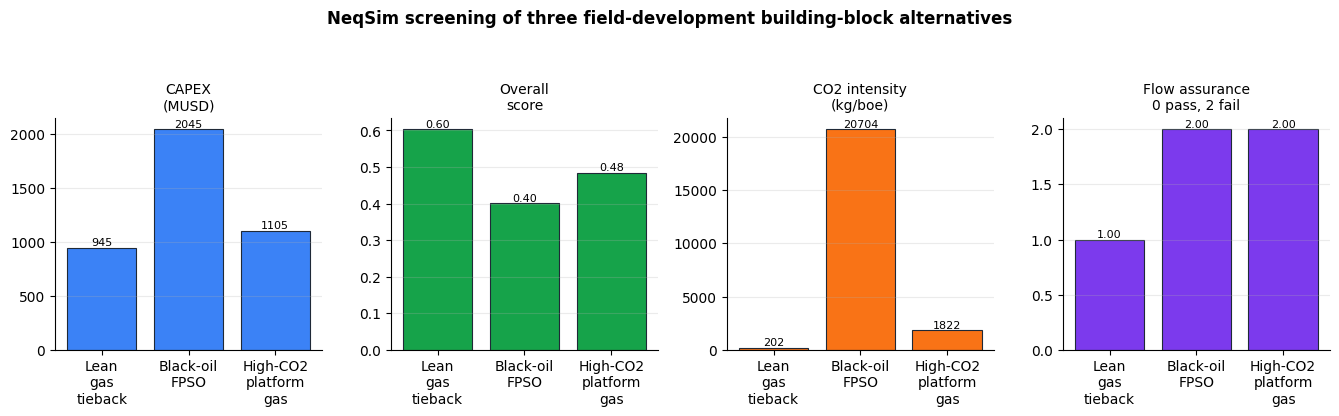

[{'name': 'Lean gas tieback',
  'capex': 945.0,
  'score': 0.6035,
  'co2': 202.34246575342465,
  'fa': 1.0,
  'fa_label': 'MARGINAL',
  'blocks': 5},
 {'name': 'Black-oil FPSO',
  'capex': 2045.0,
  'score': 0.401,
  'co2': 20704.17756526234,
  'fa': 2.0,
  'fa_label': 'FAIL',
  'blocks': 5},
 {'name': 'High-CO2 platform gas',
  'capex': 1105.0,
  'score': 0.484,
  'co2': 1821.6027397260275,
  'fa': 2.0,
  'fa_label': 'FAIL',
  'blocks': 7}]

In [3]:
concepts = []
concepts.append(FieldConcept.builder("Lean gas tieback")
    .reservoir(ReservoirInput.leanGas().gor(10000.0).co2Percent(1.5).h2sPercent(0.0).build())
    .wells(WellsInput.builder().producerCount(3).tubeheadPressure(100.0).ratePerWell(1.0e6, "Sm3/d").build())
    .infrastructure(InfrastructureInput.subseaTieback().tiebackLength(25.0).waterDepth(300.0).exportPressure(180.0).build())
    .build())
concepts.append(FieldConcept.builder("Black-oil FPSO")
    .reservoir(ReservoirInput.blackOil().gor(150.0).waterCut(0.15).build())
    .wells(WellsInput.builder().producerCount(8).injectorCount(4).tubeheadPressure(50.0).ratePerWell(5000.0, "bbl/d").build())
    .infrastructure(InfrastructureInput.builder().processingLocation(InfrastructureInput.ProcessingLocation.FPSO).waterDepth(800.0).exportType(InfrastructureInput.ExportType.STABILIZED_OIL).build())
    .build())
concepts.append(FieldConcept.builder("High-CO2 platform gas")
    .reservoir(ReservoirInput.richGas().gor(3000.0).co2Percent(15.0).h2sPercent(0.05).build())
    .wells(WellsInput.builder().producerCount(6).tubeheadPressure(120.0).ratePerWell(2.0e6, "Sm3/d").build())
    .infrastructure(InfrastructureInput.builder().processingLocation(InfrastructureInput.ProcessingLocation.PLATFORM).powerSupply(InfrastructureInput.PowerSupply.POWER_FROM_SHORE).waterDepth(150.0).build())
    .build())

evaluator = ConceptEvaluator()
screener = FlowAssuranceScreener()
ranker = DevelopmentOptionRanker()
ranker.setWeightProfile("balanced")
severity_map = {"PASS": 0.0, "MARGINAL": 1.0, "FAIL": 2.0}
rows = []

for concept in concepts:
    kpis = evaluator.evaluate(concept)
    fa_report = screener.quickScreen(concept)
    facility = FacilityBuilder.autoGenerate(concept).build()
    fa_level = str(fa_report.getOverallResult())
    row = {
        "name": str(concept.getName()),
        "capex": float(kpis.getTotalCapexMUSD()),
        "score": float(kpis.getOverallScore()),
        "co2": float(kpis.getCo2IntensityKgPerBoe()),
        "fa": severity_map.get(fa_level, 0.0),
        "fa_label": fa_level,
        "blocks": int(facility.getBlockCount()),
    }
    rows.append(row)
    option = ranker.addOption(row["name"])
    option.setScore(Criterion.NPV, float(kpis.getNpv10MUSD()))
    option.setScore(Criterion.CO2_INTENSITY, row["co2"])
    option.setScore(Criterion.TECHNICAL_RISK, row["fa"] / 2.0)
    option.setScore(Criterion.HSE_RISK, row["fa"] / 2.0)
    option.setScore(Criterion.CAPITAL_EFFICIENCY, max(row["score"], 0.01))
    option.setScore(Criterion.STRATEGIC_FIT, 0.7 if concept.isSubseaTieback() else 0.6)

ranking = ranker.rank()
print(ranking.generateReport())

names = [row["name"].replace(" ", "\n") for row in rows]
metrics = [
    ("CAPEX\n(MUSD)", [row["capex"] for row in rows], "#3b82f6"),
    ("Overall\nscore", [row["score"] for row in rows], "#16a34a"),
    ("CO2 intensity\n(kg/boe)", [row["co2"] for row in rows], "#f97316"),
    ("Flow assurance\n0 pass, 2 fail", [row["fa"] for row in rows], "#7c3aed"),
]

fig, axes = plt.subplots(1, 4, figsize=(13.5, 4.2))
for ax, (title, values, color) in zip(axes, metrics):
    bars = ax.bar(names, values, color=color, edgecolor="#1f2937", linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bar, value in zip(bars, values):
        label = f"{value:.0f}" if abs(value) >= 10 else f"{value:.2f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), label,
                ha="center", va="bottom", fontsize=8)

fig.suptitle("NeqSim screening of three field-development building-block alternatives", fontsize=12, weight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(FIGURES_DIR / "ch11_neqsim_concept_screening_results.png", dpi=160, bbox_inches="tight")
plt.show()
rows
